# **Assignment_04: Time Series Analysis of Real-World Business Data**

### **Student Name:**
Awais Manzoor

### **Instructor:**
Sir Qamar Abbas

### **Dataset:**
Apple (AAPL) Stock Price Dataset

### **Objective:**
The objective of this assignment is to analyze the stationarity of Apple stock prices using time series visualization, decomposition, ADF testing, ACF/PACF analysis, and differencing techniques.

### **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### **Load Dataset**

In [3]:
df = pd.read_csv("aapl.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2008-10-14,116.26,116.40,103.14,104.08,70749800,104.08
1,2008-10-13,104.55,110.53,101.02,110.26,54967000,110.26
2,2008-10-10,85.70,100.00,85.00,96.80,79260700,96.80
3,2008-10-09,93.35,95.80,86.60,88.74,57763700,88.74
4,2008-10-08,85.91,96.33,85.68,89.79,78847900,89.79


### **Data Preparation**

In [4]:
# Convert Date column into datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df.set_index('Date', inplace=True)

# Select Closing Price as time series
ts = df['Close']

# Display data
ts.head()

Date
2008-10-14    104.08
2008-10-13    110.26
2008-10-10     96.80
2008-10-09     88.74
2008-10-08     89.79
Name: Close, dtype: float64

### **Part 1 — Exploratory Analysis**

#### **Plot Original Time Series**

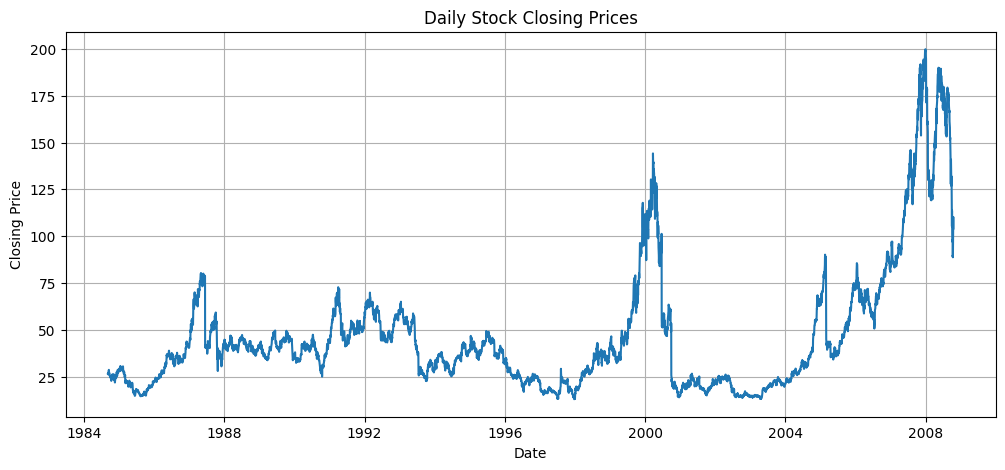

In [5]:
plt.figure(figsize=(12,5))
plt.plot(ts)
plt.title("Daily Stock Closing Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

- The time series plot shows fluctuations in stock prices over time. If the mean and variance change over time, the series may be non-stationary.

### **Time Series Decomposition**
- Trend Component
- Seasonal Component
- Residual Component

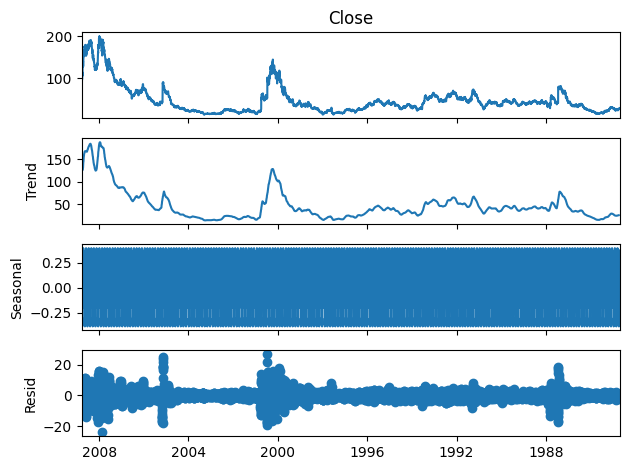

In [6]:
result = seasonal_decompose(ts, model='additive', period=30)

result.plot()

plt.show()

- The trend indicates long-term movement in stock prices, while seasonality captures repeating patterns.

## **Part 2 — Statistical Testing**

### **ADF Test**

In [8]:
# Function for ADF Test

def adf_test(series, name):

    result = adfuller(series)

    print(f"ADF Test for {name}")

    print("ADF Statistic:", result[0])

    print("p-value:", result[1])

    print("Critical Values:")

    for key, value in result[4].items():

        print(key, ":", value)



In [9]:
# Apply ADF Test

adf_test(ts, 'Original Series')

ADF Test for Original Series
ADF Statistic: -3.793436594572283
p-value: 0.002975185604126132
Critical Values:
1% : -3.4314306202311764
5% : -2.8620175355904833
10% : -2.5670241896251653


### **Plot ACF and PACF**

<Figure size 1200x500 with 0 Axes>

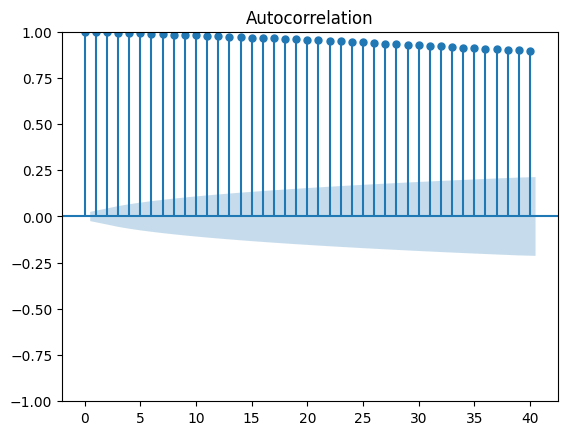

<Figure size 1200x500 with 0 Axes>

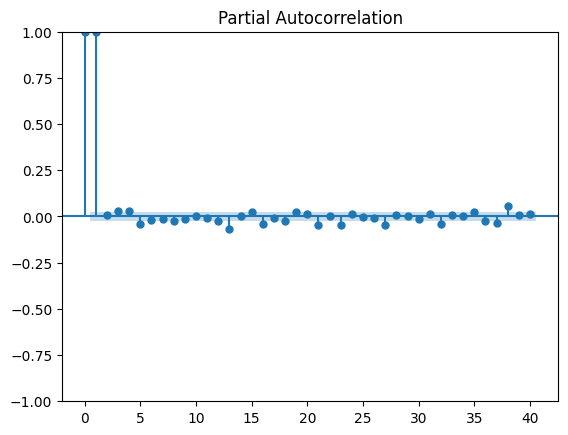

In [12]:
plt.figure(figsize=(12,5))
plot_acf(ts, lags=40)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(ts, lags=40)
plt.show()

- The ACF plot shows slow decay in autocorrelation, which suggests non-stationarity.
- The PACF plot shows significant spikes at early lags, indicating trend behavior in the series.


## **Part 3 — Transformation and Re-testing**

### **First Order Differencing**

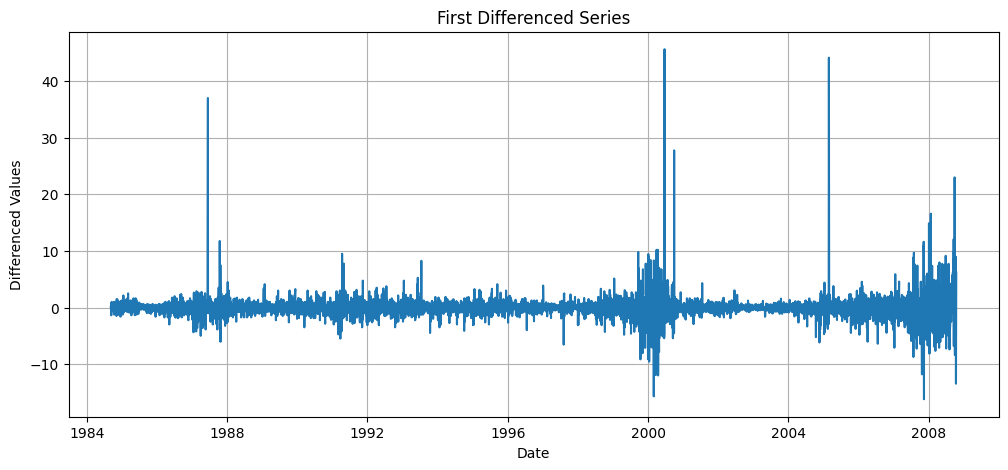

In [13]:
# Apply first differencing

diff_1 = ts.diff().dropna()

# Plot differenced series

plt.figure(figsize=(12,5))
plt.plot(diff_1)
plt.title("First Differenced Series")
plt.xlabel("Date")
plt.ylabel("Differenced Values")
plt.grid(True)
plt.show()

- After differencing, the series should fluctuate around a constant mean without strong trends.

### **ADF Test After Differencing**

In [14]:
adf_test(diff_1, 'First Differenced Series')

ADF Test for First Differenced Series
ADF Statistic: -12.981186870406042
p-value: 2.9413918177515494e-24
Critical Values:
1% : -3.4314322297790083
5% : -2.862018246734374
10% : -2.567024568185534


### **ACF and PACF After Differencing**

<Figure size 1200x500 with 0 Axes>

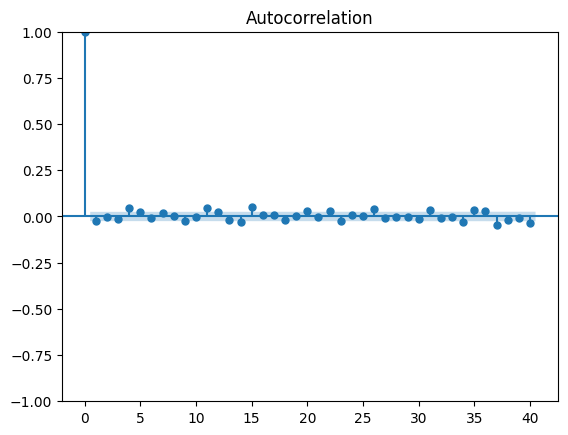

<Figure size 1200x500 with 0 Axes>

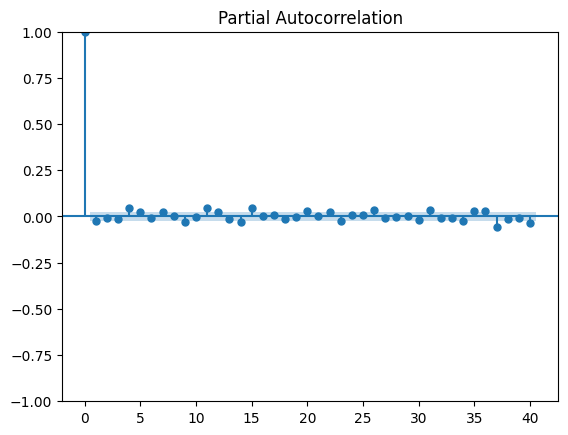

In [15]:
plt.figure(figsize=(12,5))
plot_acf(diff_1, lags=40)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(diff_1, lags=40)
plt.show()